这个ipynb主要是针对如果通过程序模块化的对算子进行融合操作,而不是手动的自己编写算子.通过已有的算子库来对算子进行融合操作

In [3]:
import numpy as np
import tvm
from tvm import relax, topi
from tvm.ir.module import IRModule
from tvm.script import relax as R
from tvm.script import tir as T

In [3]:
@tvm.script.ir_module
class MyModule:
    @R.function
    def main(x: R.Tensor((3, 4), "float32"), y: R.Tensor((3, 4), "float32")):
        with R.dataflow():
            lv0 = relax.op.multiply(x, y)
            gv0 = relax.op.add(lv0, y)
            R.output(gv0)
        return gv0

MyModule 包含一个带有两个图层 op 的 relax 函数，其中包含 relax.op.multiply 和relax.op.add。我们的目标是找到这两个运算符并将它们替换为一个 relax.op.ewise_fma 运算符的调用。

在我们研究如何准确地做到这一点之前，让我们首先检查构成 MyModule 的数据结构。 每个 IRModule 都包含一组函数，函数体由一组称为抽象语法树（AST）的数据结构组成。

In [5]:
relax_func = MyModule["main"]
type(relax_func)

tvm.relax.expr.Function

In [6]:
relax_func.params

[x, y]

In [7]:
func_body = relax_func.body
type(func_body)

tvm.relax.expr.SeqExpr

In [8]:
func_body.blocks

[x: R.Tensor((3, 4), dtype="float32")
y: R.Tensor((3, 4), dtype="float32")
with R.dataflow():
    lv0: R.Tensor((3, 4), dtype="float32") = R.multiply(x, y)
    gv0: R.Tensor((3, 4), dtype="float32") = R.add(lv0, y)
    R.output(gv0)]

In [11]:
dataflow_block = func_body.blocks[0]
dataflow_block.bindings

[x: R.Tensor((3, 4), dtype="float32")
y: R.Tensor((3, 4), dtype="float32")
lv0: R.Tensor((3, 4), dtype="float32") = R.multiply(x, y), lv0: R.Tensor((3, 4), dtype="float32")
y: R.Tensor((3, 4), dtype="float32")
gv0: R.Tensor((3, 4), dtype="float32") = R.add(lv0, y)]

In [12]:
@relax.expr_functor.mutator
class EwiseFMARewriter(relax.PyExprMutator):
    def visit_call_(self, call):
        call = self.visit_expr_post_order(call)
        add_op = tvm.ir.Op.get("relax.add")
        multiply_op = tvm.ir.Op.get("relax.multiply")
        ewise_fma_op = tvm.ir.Op.get("relax.ewise_fma")

        if call.op != add_op:
            return call

        value = self.lookup_binding(call.args[0])
        if not isinstance(value, relax.Call) or value.op != multiply_op:
            return call

        fma_call = relax.Call(
            ewise_fma_op, [value.args[0], value.args[1], call.args[1]], None, None
        )
        return fma_call


updated_fn = EwiseFMARewriter().visit_expr(MyModule["main"])
updated_fn.show()

In [13]:
#请注意，结果将 gv0 重写为融合运算符，但将 lv0 留在代码中。 我们可以使用 remove_all_unused 来进一步简化代码块。

relax.analysis.remove_all_unused(updated_fn).show()

融合 Linear 和 ReLU 算子

In [1]:
# Hide outputs
!wget https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl

--2025-02-27 21:32:49--  https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl [following]
--2025-02-27 21:32:50--  https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407396 (398K) [application/octet-stream]
Saving to: ‘fasionmnist_mlp_params.pkl’

fasionmnist_mlp_par 100%[===================>] 397.85K   190KB/s    in 2.1s    

2025-02-27 21:32:52 (190 KB/s) - ‘fasionmnist_mlp_param

In [4]:
import pickle as pkl

mlp_params = pkl.load(open("fasionmnist_mlp_params.pkl", "rb"))
def create_model():
    bb = relax.BlockBuilder()
    x = relax.Var("x", relax.TensorStructInfo((1, 784), "float32"))
    w0 = relax.const(mlp_params["w0"], "float32")
    b0 = relax.const(mlp_params["b0"], "float32")
    w1 = relax.const(mlp_params["w1"], "float32")
    b1 = relax.const(mlp_params["b1"], "float32")
    with bb.function("main", [x]):
        with bb.dataflow():
            lv0 = bb.emit(relax.op.matmul(x, relax.op.permute_dims(w0)))
            lv1 = bb.emit(relax.op.add(lv0, b0))
            lv2 = bb.emit(relax.op.nn.relu(lv1))
            lv3 = bb.emit(relax.op.matmul(lv2, relax.op.permute_dims(w1)))
            lv4 = bb.emit(relax.op.add(lv3, b1))
            gv = bb.emit_output(lv4)
        bb.emit_func_output(gv)

    return bb.get()

MLPModel = create_model()
MLPModel.show()

我们的目标是“融合” matmul 和 add 算子到一起。 以下代码通过以下步骤实现：

识别 matmul 和 add 算子。

生成另一个调用 matmul 和 add 算子的子函数。

将 matmul 和 add 替换为融合后的子函数。

In [5]:
@relax.expr_functor.mutator
class MatmulAddFusor(relax.PyExprMutator):
    def __init__(self, mod: IRModule) -> None:
        super().__init__()
        self.mod_ = mod
        # cache pre-defined ops
        self.add_op = tvm.ir.Op.get("relax.add")
        self.matmul_op = tvm.ir.Op.get("relax.matmul")
        self.counter = 0

    def transform(self) -> IRModule:
        for global_var, func in self.mod_.functions.items():
            if not isinstance(func, relax.Function):
                continue
            # avoid already fused primitive functions
            if func.attrs is not None and "Primitive" in func.attrs.keys() and func.attrs["Primitive"] != 0:
                continue
            updated_func = self.visit_expr(func)
            updated_func = relax.analysis.remove_all_unused(updated_func)
            self.builder_.update_func(global_var, updated_func)

        return self.builder_.get()

    def visit_call_(self, call):
        call = self.visit_expr_post_order(call)

        def match_call(node, op):
            if not isinstance(node, relax.Call):
                return False
            return node.op == op

        # pattern match matmul => add
        if not match_call(call, self.add_op):
            return call

        value = self.lookup_binding(call.args[0])
        if value is None:
            return call

        if not match_call(value, self.matmul_op):
            return call

        x = value.args[0]
        w = value.args[1]
        b = call.args[1]

        # construct a new fused primitive function
        param_x = relax.Var("x" ,relax.TensorStructInfo(x.struct_info.shape, x.struct_info.dtype))
        param_w = relax.Var("w" ,relax.TensorStructInfo(w.struct_info.shape, w.struct_info.dtype))
        param_b = relax.Var("b" ,relax.TensorStructInfo(b.struct_info.shape, b.struct_info.dtype))

        bb = relax.BlockBuilder()

        fn_name = "fused_matmul_add%d" % (self.counter)
        self.counter += 1
        with bb.function(fn_name, [param_x, param_w, param_b]):
            with bb.dataflow():
                lv0 = bb.emit(relax.op.matmul(param_x, param_w))
                gv = bb.emit_output(relax.op.add(lv0, param_b))
            bb.emit_func_output(gv)

        # Add Primitive attribute to the fused funtions
        fused_fn = bb.get()[fn_name].with_attr("Primitive", 1)
        global_var = self.builder_.add_func(fused_fn, fn_name)

        # construct call into the fused function
        return relax.Call(global_var, [x, w, b], None, None)

@tvm.ir.transform.module_pass(opt_level=2, name="MatmulAddFuse")
class FuseDenseAddPass:
    """The wrapper for the LowerTensorIR pass."""
    def transform_module(self, mod, ctx):
        return MatmulAddFusor(mod).transform()


MLPFused = FuseDenseAddPass()(MLPModel)
MLPFused.show()

在上面的例子中，我们创建了两个前缀为 fuse_matmul_add 的子函数。 这些子函数包含有融合后算子的计算信息。 这种重写的替代方法是简单地为融合运算符创建一个单独的原始操作（如ewise_fma）。 但是，当我们尝试融合更多运算符时，可能存在指数级数量的组合。 将融合操作分组在一起的子函数为后续的 pass 保留了原始信息，进而便于分析，无需为每个融合 pattern 引入专用的高级运算符。

In [6]:
@relax.expr_functor.mutator
class LowerToTensorIR(relax.PyExprMutator):
    def __init__(self, mod: IRModule, op_map) -> None:
        super().__init__()
        self.mod_ = mod
        self.op_map = {
            tvm.ir.Op.get(k): v for k, v in op_map.items()
        }


    def visit_call_(self, call):
        call = self.visit_expr_post_order(call)

        if call.op in self.op_map:
            return self.op_map[call.op](self.builder_, call)
        return call

    def transform(self) -> IRModule:
        for global_var, func in self.mod_.functions.items():
            if not isinstance(func, relax.Function):
                continue
            updated_func = self.visit_expr(func)
            self.builder_.update_func(global_var, updated_func)

        return self.builder_.get()


def map_matmul(bb, call):
    x, w = call.args
    return bb.call_te(topi.nn.matmul, x, w)

def map_add(bb, call):
    a, b = call.args
    return bb.call_te(topi.add, a, b)

def map_relu(bb, call):
    return bb.call_te(topi.nn.relu, call.args[0])

def map_transpose(bb, call):
    return bb.call_te(topi.transpose, call.args[0], )

op_map = {
  "relax.matmul": map_matmul,
  "relax.add": map_add,
  "relax.nn.relu": map_relu,
  "relax.permute_dims": map_transpose
}

@tvm.ir.transform.module_pass(opt_level=0, name="LowerToTensorIR")
class LowerToTensorIRPass:
    """The wrapper for the LowerTensorIR pass."""
    def transform_module(self, mod, ctx):
        return LowerToTensorIR(mod, op_map).transform()


MLPModelTIR = LowerToTensorIRPass()(MLPFused)
MLPModelTIR.show()

In [7]:
# 请注意，在上面的代码中。 fused_matmul_add0 和 fused_matmul_add1 仍然是上层 relax 函数，它们调用相应的 TensorIR matmul 和 add 函数。 
# 我们可以将它们变成一个单一的 TensorIR 函数，然后可以用于后续优化和代码生成阶段。
MLPModelFinal = relax.transform.FuseTIR()(MLPModelTIR)
MLPModelFinal.show()

构建并运行

100.0%


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



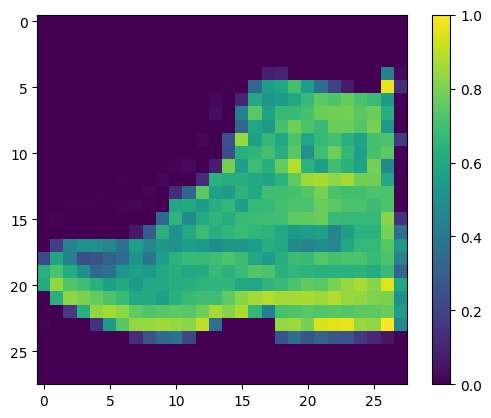

Class: Ankle boot


In [8]:
# Hide outputs
import torch
import torchvision

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

img, label = next(iter(test_loader))
img = img.reshape(1, 28, 28).numpy()
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img[0])
plt.colorbar()
plt.grid(False)
plt.show()

print("Class:", class_names[label[0]])

In [13]:
import tvm

# 检查 TVM 是否支持 CUDA
print("TVM supports CUDA:", tvm.cuda().exist)

# 获取 TVM 构建时的 CUDA 版本信息
print("\n".join(f"{k}: {v}" for k, v in tvm.support.libinfo().items() if "CUDA" in k))

#这里是因为安装的mlc-cuda的安装包出了点问题验证使用
#最后用的是mlc_ai_nightly_cu124-0.20.dev45-cp38-cp38-manylinux_2_28_x86_64.whl能够验证成功

TVM supports CUDA: True
CUDA_VERSION: 12.4
USE_GRAPH_EXECUTOR_CUDA_GRAPH: OFF
USE_CUDA: ON


In [15]:
ex = relax.build(MLPModelFinal, target="llvm")
vm = relax.VirtualMachine(ex, tvm.cpu())
data_nd = tvm.nd.array(img.reshape(1, 784))

nd_res = vm["main"](data_nd)

pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MLPModule Prediction:", class_names[pred_kind[0]])

MLPModule Prediction: Ankle boot
